# 🫀 Heart Disease Prediction using Machine Learning
### Classification Project

**Goal:** Predict whether a patient has heart disease based on medical attributes.

**Models Used:** KNN · SVM · Decision Tree · Random Forest

**Tools:** Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn · MLflow


In [1]:
# ============================================================
# 1. IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import mlflow
import mlflow.sklearn
import os

# Plotting style
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

PLOTS_DIR = '../plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 📂 Section 1 — Data Loading

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================
df = pd.read_csv('../data/heart_dataset.csv')

print("─" * 50)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("─" * 50)
print("\n📌 First 5 rows:")
display(df.head())


──────────────────────────────────────────────────
Dataset Shape: 3000 rows × 14 columns
──────────────────────────────────────────────────

📌 First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Dataset info
print("\n📌 Dataset Info:")
df.info()



📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3000 non-null   int64  
 1   sex       3000 non-null   int64  
 2   cp        3000 non-null   int64  
 3   trestbps  3000 non-null   int64  
 4   chol      3000 non-null   int64  
 5   fbs       3000 non-null   int64  
 6   restecg   3000 non-null   int64  
 7   thalach   3000 non-null   int64  
 8   exang     3000 non-null   int64  
 9   oldpeak   3000 non-null   float64
 10  slope     3000 non-null   int64  
 11  ca        3000 non-null   int64  
 12  thal      3000 non-null   int64  
 13  target    3000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 328.3 KB


In [4]:
# Statistical summary
print("\n📌 Statistical Summary:")
display(df.describe().round(2))



📌 Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,54.67,0.70,0.96,131.70,244.52,0.16,0.52,148.71,0.33,1.10,1.37,0.77,2.32,0.52
std,9.01,0.46,1.04,18.09,50.95,0.37,0.53,23.14,0.47,1.17,0.62,1.04,0.64,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,209.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,239.00,0.00,1.00,151.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,141.00,274.00,0.00,1.00,165.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## 🧹 Section 2 — Data Cleaning

In [5]:
# ============================================================
# DATA CLEANING
# ============================================================

# Missing values
missing = df.isnull().sum()
print("📌 Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "  ✅ No missing values found!")

# Duplicates
dups = df.duplicated().sum()
print(f"\n📌 Duplicate Rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"  ⚠️  Removed {dups} duplicate(s). New shape: {df.shape}")
else:
    print("  ✅ No duplicates found!")

# Data types
print("\n📌 Data Types:")
print(df.dtypes)


📌 Missing Values per Column:
  ✅ No missing values found!

📌 Duplicate Rows: 723
  ⚠️  Removed 723 duplicate(s). New shape: (2277, 14)

📌 Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [6]:
# Validate value ranges for known columns
checks = {
    'sex':    (0, 1),
    'cp':     (0, 3),
    'fbs':    (0, 1),
    'restecg':(0, 2),
    'exang':  (0, 1),
    'slope':  (0, 2),
    'ca':     (0, 4),
    'thal':   (0, 3),
    'target': (0, 1),
}
print("📌 Value Range Validation:")
for col, (lo, hi) in checks.items():
    invalid = ((df[col] < lo) | (df[col] > hi)).sum()
    status = "✅ OK" if invalid == 0 else f"⚠️  {invalid} invalid value(s)"
    print(f"  {col:10s} [{lo}–{hi}]  →  {status}")

print("\n✅ Data cleaning complete!")


📌 Value Range Validation:
  sex        [0–1]  →  ✅ OK
  cp         [0–3]  →  ✅ OK
  fbs        [0–1]  →  ✅ OK
  restecg    [0–2]  →  ✅ OK
  exang      [0–1]  →  ✅ OK
  slope      [0–2]  →  ✅ OK
  ca         [0–4]  →  ✅ OK
  thal       [0–3]  →  ✅ OK
  target     [0–1]  →  ✅ OK

✅ Data cleaning complete!


## 📊 Section 3 — Exploratory Data Analysis (EDA)

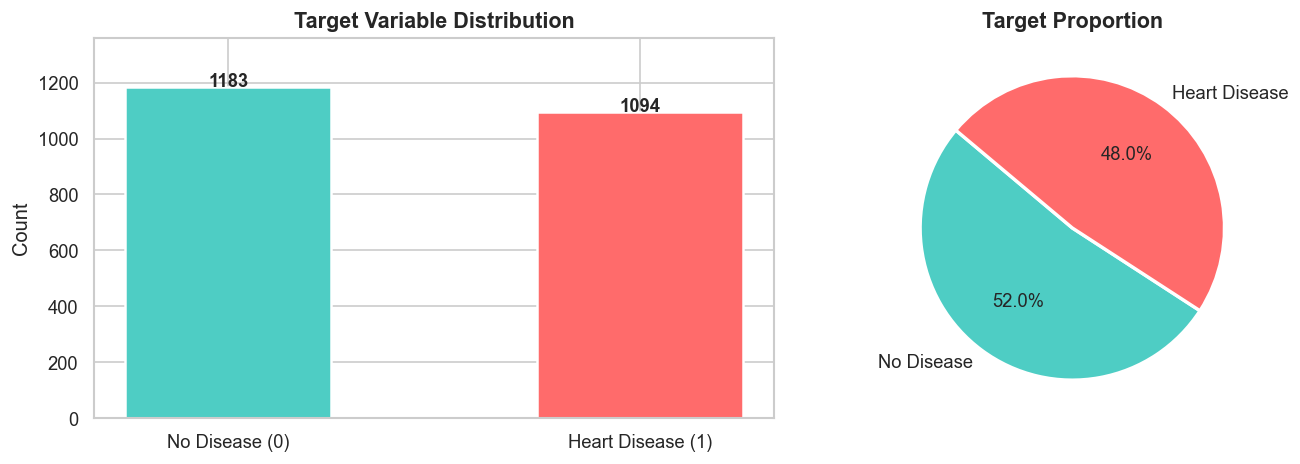

💾 Saved → plots/01_target_distribution.png


In [7]:
# ============================================================
# EDA — Target Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
counts = df['target'].value_counts()
bars = axes[0].bar(['No Disease (0)', 'Heart Disease (1)'],
                   counts.values,
                   color=['#4ECDC4', '#FF6B6B'], edgecolor='white', linewidth=1.5,
                   width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie
axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            colors=['#4ECDC4', '#FF6B6B'], autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Target Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_target_distribution.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/01_target_distribution.png")


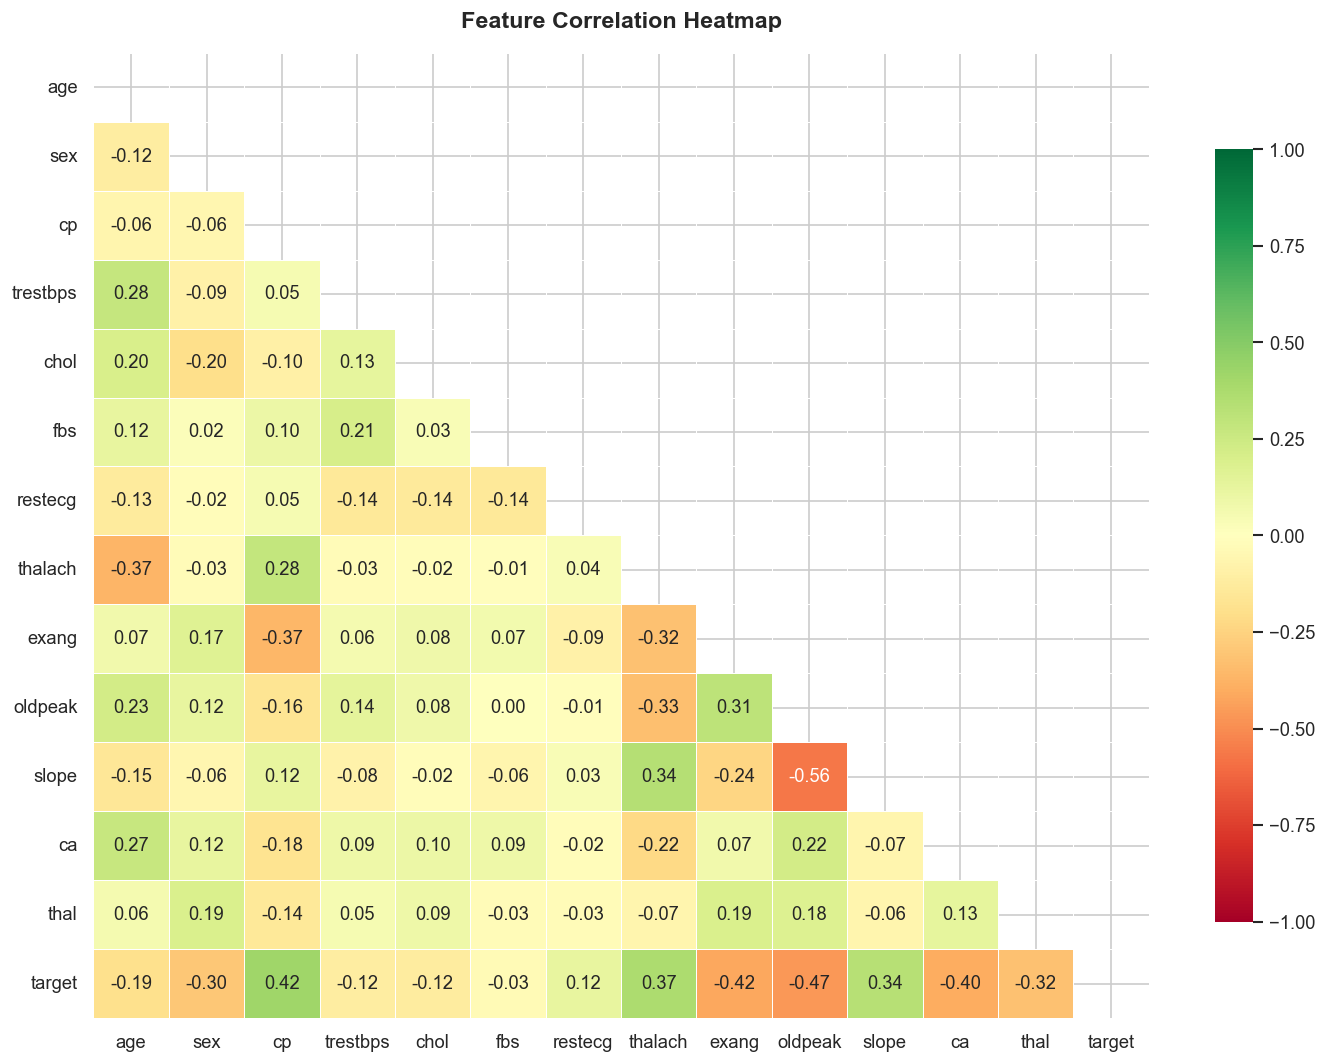

💾 Saved → plots/02_correlation_heatmap.png


In [8]:
# ============================================================
# EDA — Correlation Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(12, 9))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', linewidths=0.5,
            cmap='RdYlGn', vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/02_correlation_heatmap.png")


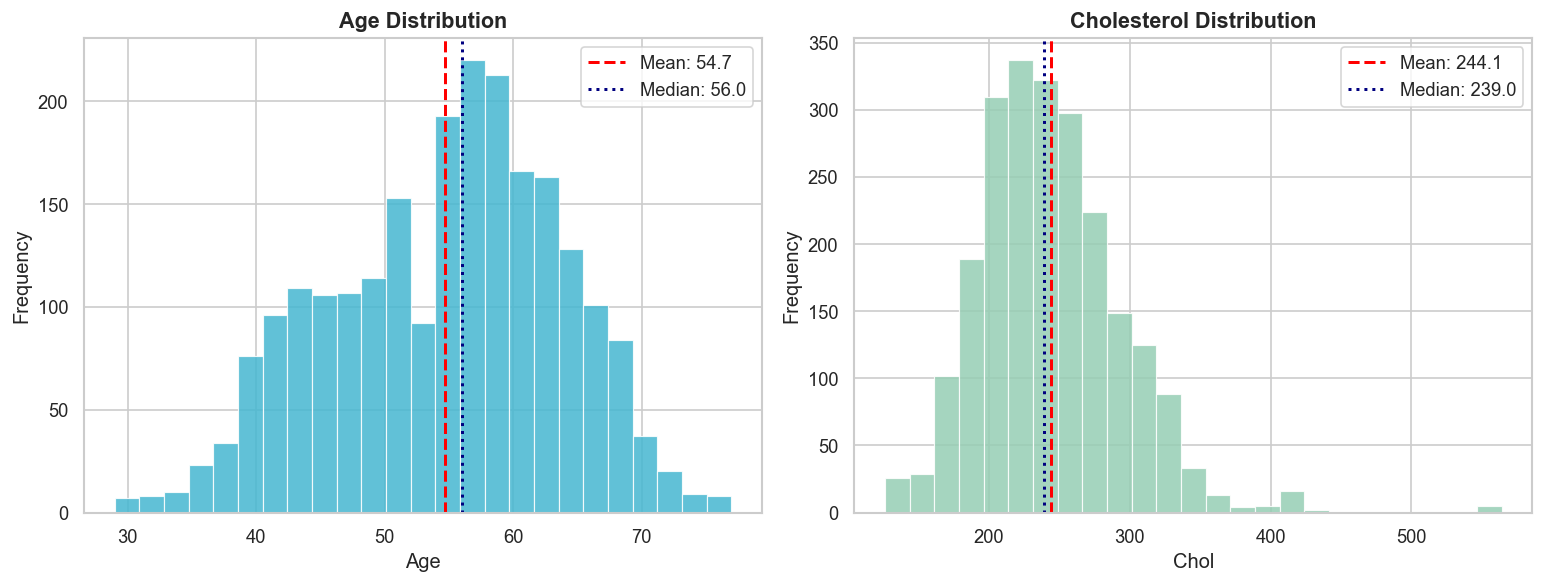

💾 Saved → plots/03_age_chol_histograms.png


In [9]:
# ============================================================
# EDA — Age & Cholesterol Histograms
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, title in zip(
    axes,
    ['age', 'chol'],
    ['#45B7D1', '#96CEB4'],
    ['Age Distribution', 'Cholesterol Distribution']
):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', linewidth=0.7, alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.8,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='navy', linestyle=':', linewidth=1.8,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_age_chol_histograms.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/03_age_chol_histograms.png")


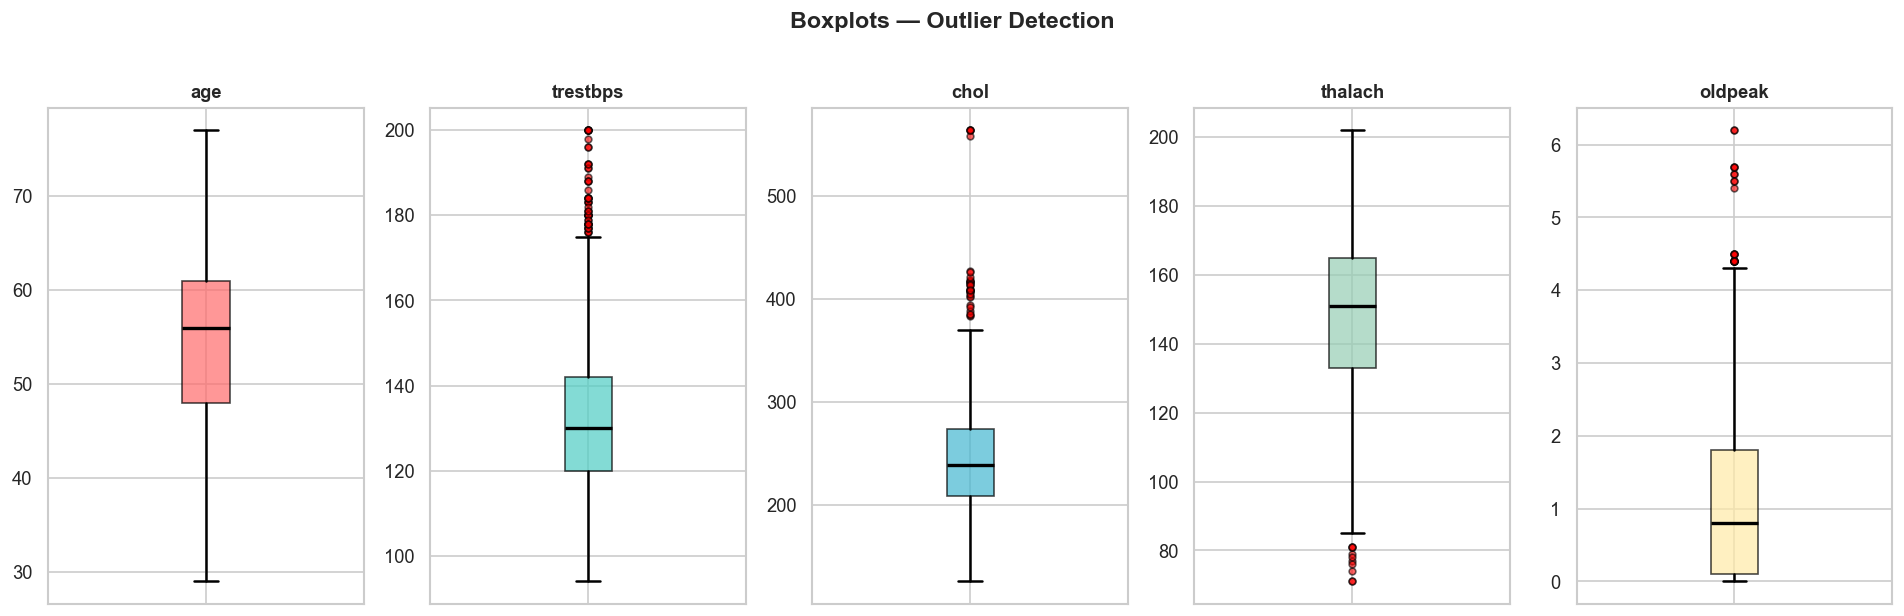

💾 Saved → plots/04_boxplots_outliers.png


In [10]:
# ============================================================
# EDA — Boxplots for Outlier Detection
# ============================================================
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for ax, col, color in zip(axes, numeric_cols, palette):
    bp = ax.boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=4, alpha=0.6))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xticklabels([])

fig.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_boxplots_outliers.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/04_boxplots_outliers.png")


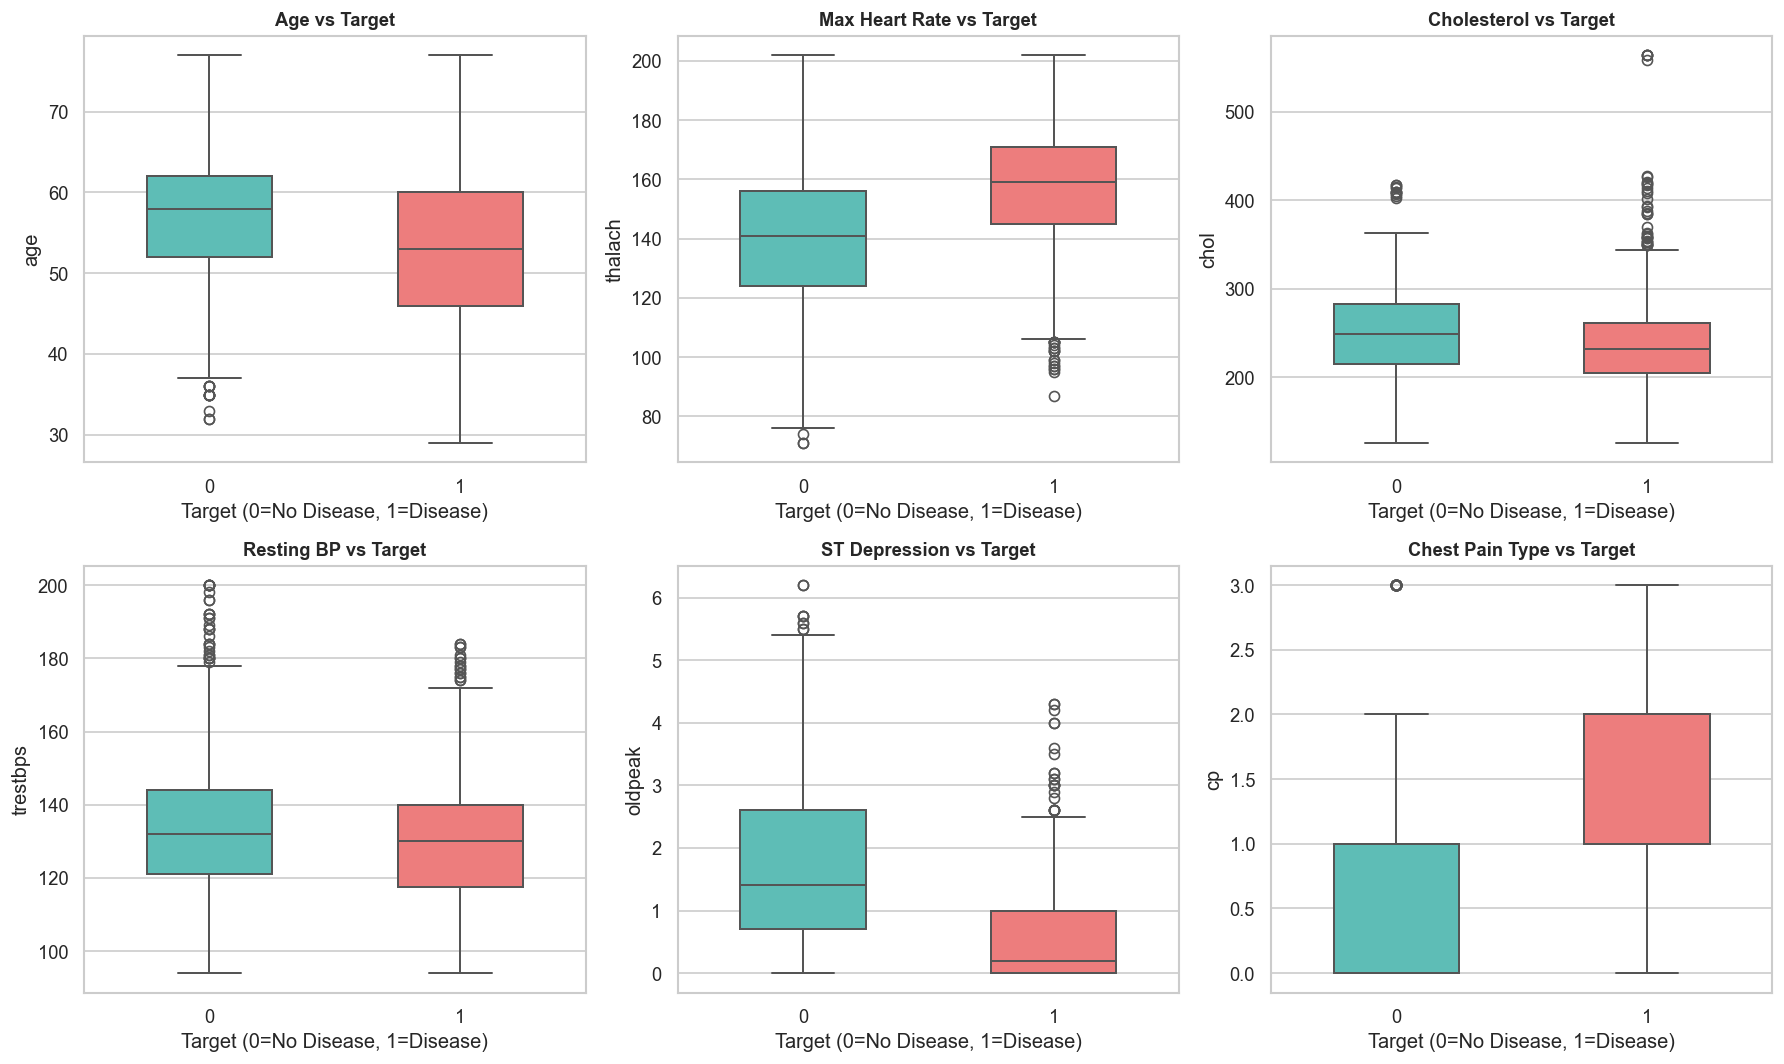

💾 Saved → plots/05_feature_vs_target.png


In [11]:
# ============================================================
# EDA — Feature Relationships vs Target
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

features = ['age', 'thalach', 'chol', 'trestbps', 'oldpeak', 'cp']
titles   = ['Age vs Target', 'Max Heart Rate vs Target',
            'Cholesterol vs Target', 'Resting BP vs Target',
            'ST Depression vs Target', 'Chest Pain Type vs Target']

for ax, feat, title in zip(axes, features, titles):
    sns.boxplot(x='target', y=feat, data=df,
                palette=['#4ECDC4', '#FF6B6B'], ax=ax,
                width=0.5, linewidth=1.2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Target (0=No Disease, 1=Disease)')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_feature_vs_target.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/05_feature_vs_target.png")


## ⚙️ Section 4 — Data Preprocessing

In [12]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

# Split features & target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test  set: {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Preprocessing complete — data is scaled and split.")


Features (X) shape : (2277, 13)
Target   (y) shape : (2277,)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Train set: 1821 samples
Test  set: 456 samples

✅ Preprocessing complete — data is scaled and split.


## 🤖 Section 5 — Machine Learning Models

In [13]:
# ============================================================
# HELPER FUNCTION — Evaluate a model
# ============================================================
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name="Model"):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
          target_names=['No Disease', 'Heart Disease']))

    return {
        'name': name, 'model': model, 'y_pred': y_pred,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'cm': cm
    }


In [14]:
# ============================================================
# TRAIN ALL MODELS
# ============================================================
results = {}

# 1. K-Nearest Neighbors
results['KNN'] = evaluate_model(
    KNeighborsClassifier(n_neighbors=5),
    X_train_scaled, X_test_scaled, y_train, y_test, 'K-Nearest Neighbors (KNN)'
)

# 2. Support Vector Machine
results['SVM'] = evaluate_model(
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test, 'Support Vector Machine (SVM)'
)

# 3. Decision Tree
results['DT'] = evaluate_model(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test, 'Decision Tree Classifier'
)

# 4. Random Forest
results['RF'] = evaluate_model(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest Classifier'
)



  K-Nearest Neighbors (KNN)
  Accuracy  : 0.9846  (98.46%)
  Precision : 0.9713
  Recall    : 1.0000
  F1-Score  : 0.9854

  Classification Report:
               precision    recall  f1-score   support

   No Disease       1.00      0.97      0.98       219
Heart Disease       0.97      1.00      0.99       237

     accuracy                           0.98       456
    macro avg       0.99      0.98      0.98       456
 weighted avg       0.99      0.98      0.98       456


  Support Vector Machine (SVM)
  Accuracy  : 0.9561  (95.61%)
  Precision : 0.9465
  Recall    : 0.9705
  F1-Score  : 0.9583

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.97      0.94      0.95       219
Heart Disease       0.95      0.97      0.96       237

     accuracy                           0.96       456
    macro avg       0.96      0.96      0.96       456
 weighted avg       0.96      0.96      0.96       456


  Decision Tree Classifier
  Acc

## 📉 Section 6 — Confusion Matrices

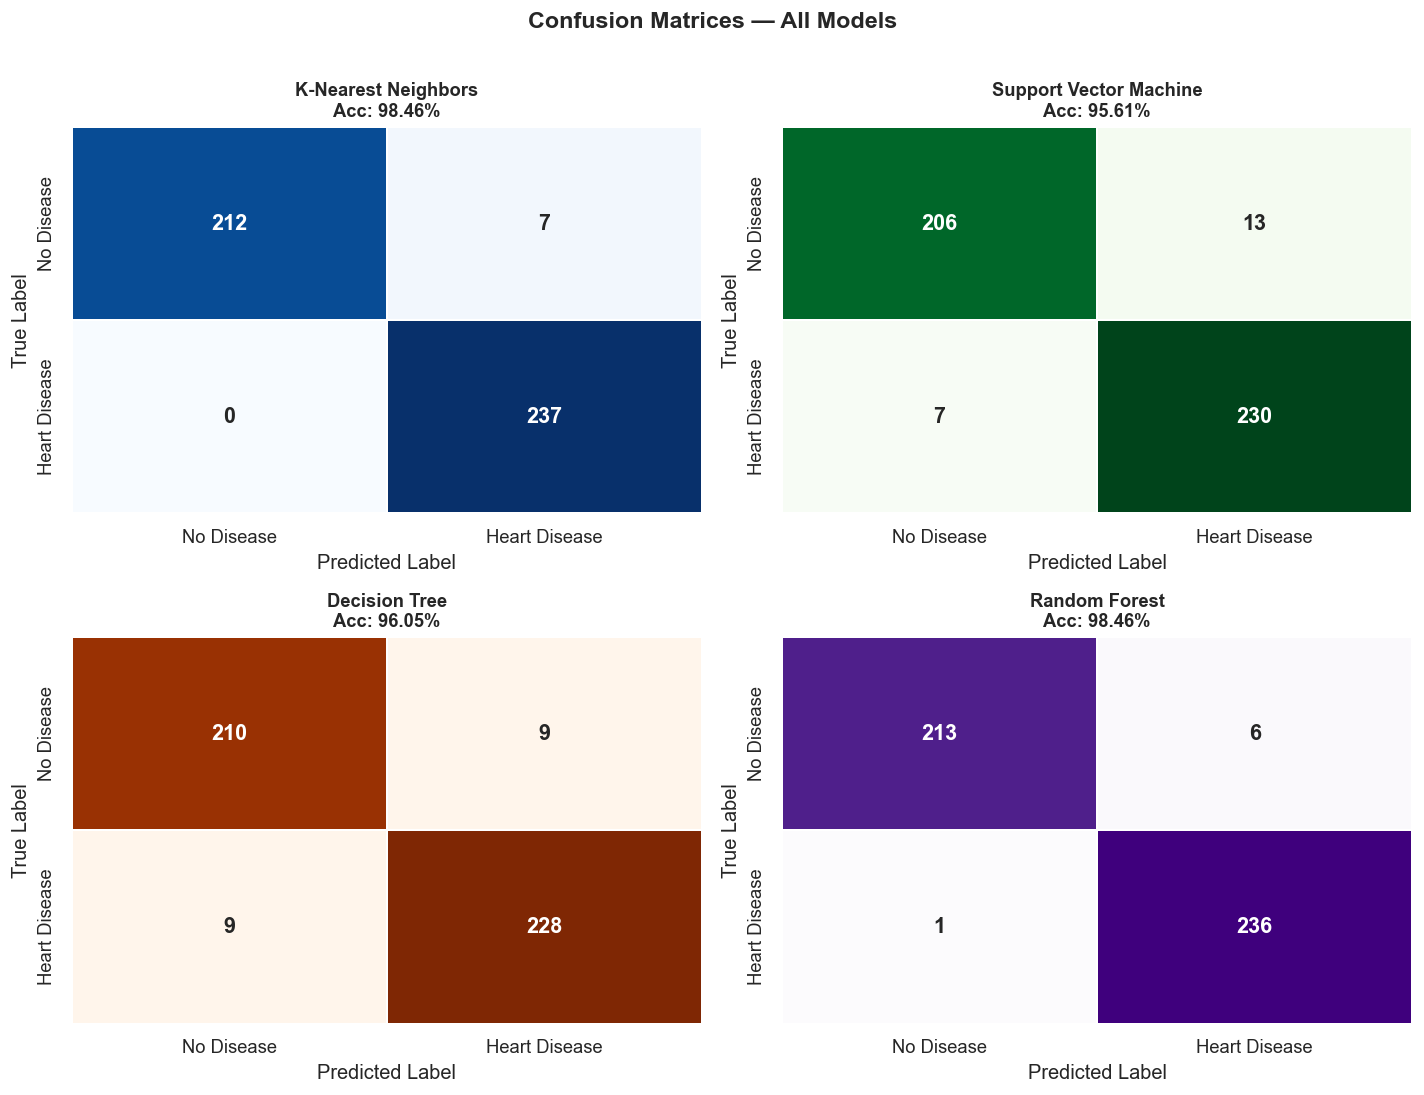

💾 Saved → plots/06_confusion_matrices.png


In [15]:
# ============================================================
# CONFUSION MATRICES — All Models
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

model_order = ['KNN', 'SVM', 'DT', 'RF']
model_names = {
    'KNN': 'K-Nearest Neighbors',
    'SVM': 'Support Vector Machine',
    'DT':  'Decision Tree',
    'RF':  'Random Forest'
}
cmap_list = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, key, cmap in zip(axes, model_order, cmap_list):
    cm = results[key]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                linewidths=1, linecolor='white', ax=ax,
                cbar=False, annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f"{model_names[key]}\nAcc: {results[key]['accuracy']*100:.2f}%",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/06_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/06_confusion_matrices.png")


## 📋 Section 7 — Model Comparison

In [16]:
# ============================================================
# COMPARISON TABLE
# ============================================================
comparison_df = pd.DataFrame([
    {
        'Model':     model_names[k],
        'Accuracy':  f"{results[k]['accuracy']*100:.2f}%",
        'Precision': f"{results[k]['precision']*100:.2f}%",
        'Recall':    f"{results[k]['recall']*100:.2f}%",
        'F1-Score':  f"{results[k]['f1']*100:.2f}%"
    }
    for k in model_order
])

print("\n📊 Model Performance Comparison:")
display(comparison_df)

# Best model
best_key = max(model_order, key=lambda k: results[k]['accuracy'])
print(f"\n🏆 Best Model: {model_names[best_key]} "
      f"(Accuracy: {results[best_key]['accuracy']*100:.2f}%)")



📊 Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbors,98.46%,97.13%,100.00%,98.54%
1,Support Vector Machine,95.61%,94.65%,97.05%,95.83%
2,Decision Tree,96.05%,96.20%,96.20%,96.20%
3,Random Forest,98.46%,97.52%,99.58%,98.54%



🏆 Best Model: K-Nearest Neighbors (Accuracy: 98.46%)


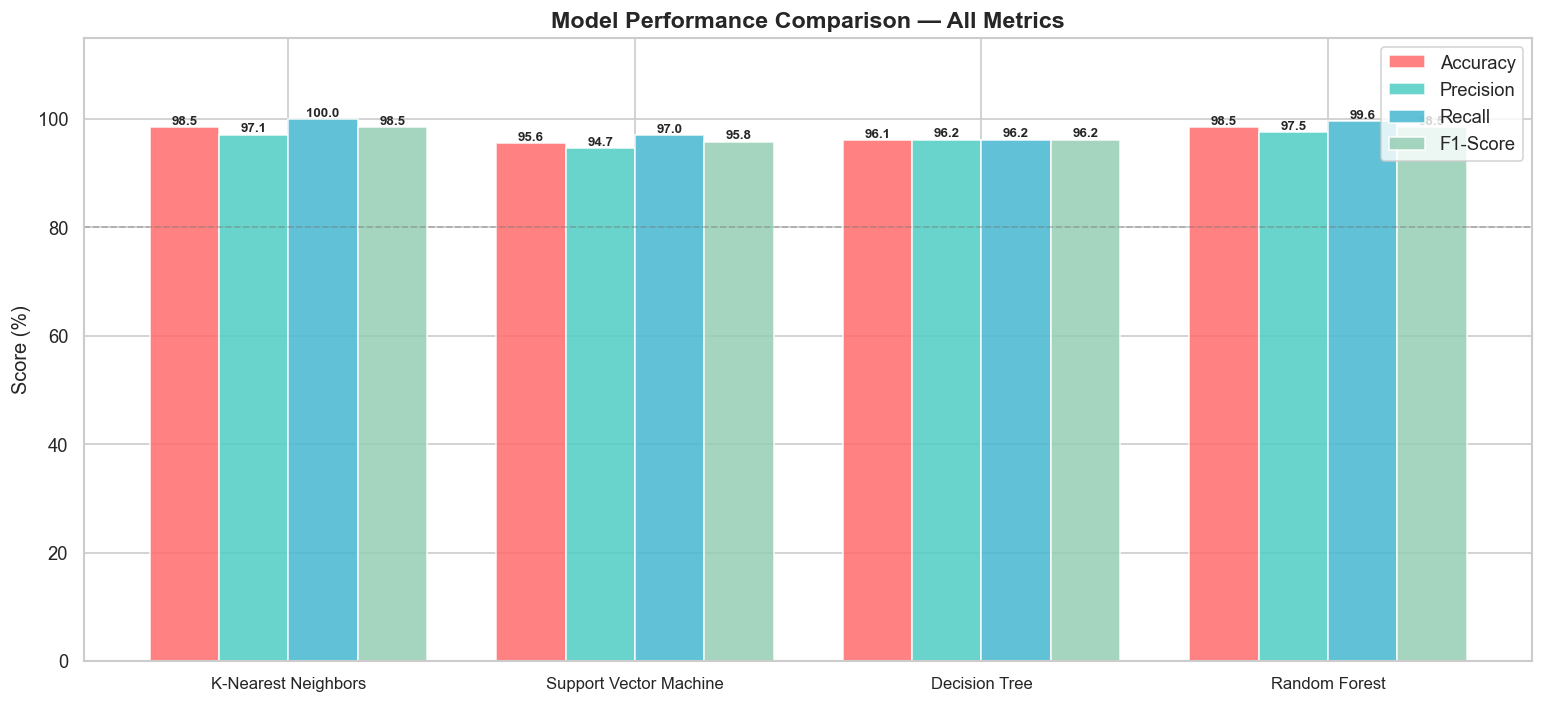

💾 Saved → plots/07_model_comparison.png


In [17]:
# ============================================================
# COMPARISON BAR CHART
# ============================================================
metrics = ['accuracy', 'precision', 'recall', 'f1']
labels  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

x = np.arange(len(model_order))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    vals = [results[k][metric] * 100 for k in model_order]
    bars = ax.bar(x + i * width, vals, width, label=label,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([model_names[k] for k in model_order], fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/07_model_comparison.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/07_model_comparison.png")


## 🔧 Section 8 — Hyperparameter Tuning (GridSearchCV)

In [18]:
# ============================================================
# TUNING 1 — KNN
# ============================================================
print("🔍 Tuning K-Nearest Neighbors...")
knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15], 'metric': ['euclidean', 'manhattan']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5,
                        scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
acc_knn_tuned = accuracy_score(y_test, y_pred_knn)

print(f"  Best Params : {knn_grid.best_params_}")
print(f"  CV Score    : {knn_grid.best_score_*100:.2f}%")
print(f"  Before      : {results['KNN']['accuracy']*100:.2f}%")
print(f"  After Tuning: {acc_knn_tuned*100:.2f}%")


🔍 Tuning K-Nearest Neighbors...
  Best Params : {'metric': 'manhattan', 'n_neighbors': 3}
  CV Score    : 99.40%
  Before      : 98.46%
  After Tuning: 98.68%


In [19]:
# ============================================================
# TUNING 2 — SVM
# ============================================================
print("🔍 Tuning Support Vector Machine...")
svm_params = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5,
                        scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
acc_svm_tuned = accuracy_score(y_test, y_pred_svm)

print(f"  Best Params : {svm_grid.best_params_}")
print(f"  CV Score    : {svm_grid.best_score_*100:.2f}%")
print(f"  Before      : {results['SVM']['accuracy']*100:.2f}%")
print(f"  After Tuning: {acc_svm_tuned*100:.2f}%")


🔍 Tuning Support Vector Machine...
  Best Params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  CV Score    : 99.18%
  Before      : 95.61%
  After Tuning: 99.56%


In [20]:
# ============================================================
# TUNING 3 — Random Forest
# ============================================================
print("🔍 Tuning Random Forest...")
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10],
             'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                       cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
acc_rf_tuned = accuracy_score(y_test, y_pred_rf)

print(f"  Best Params : {rf_grid.best_params_}")
print(f"  CV Score    : {rf_grid.best_score_*100:.2f}%")
print(f"  Before      : {results['RF']['accuracy']*100:.2f}%")
print(f"  After Tuning: {acc_rf_tuned*100:.2f}%")


🔍 Tuning Random Forest...
  Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
  CV Score    : 99.12%
  Before      : 98.46%
  After Tuning: 98.46%


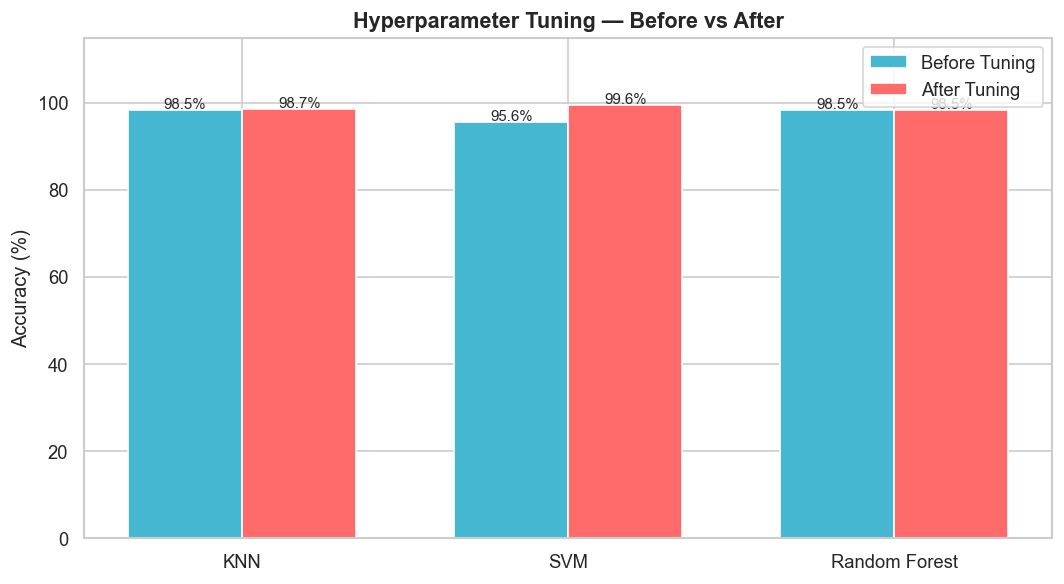

💾 Saved → plots/08_hyperparameter_tuning.png


In [21]:
# ============================================================
# BEFORE vs AFTER TUNING — Chart
# ============================================================
tuning_data = {
    'KNN': (results['KNN']['accuracy']*100, acc_knn_tuned*100),
    'SVM': (results['SVM']['accuracy']*100, acc_svm_tuned*100),
    'RF':  (results['RF']['accuracy']*100,  acc_rf_tuned*100),
}

x = np.arange(len(tuning_data))
width = 0.35
labels_t = list(tuning_data.keys())

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [v[0] for v in tuning_data.values()],
               width, label='Before Tuning', color='#45B7D1', edgecolor='white')
bars2 = ax.bar(x + width/2, [v[1] for v in tuning_data.values()],
               width, label='After Tuning', color='#FF6B6B', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['KNN', 'SVM', 'Random Forest'])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('Hyperparameter Tuning — Before vs After', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/08_hyperparameter_tuning.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/08_hyperparameter_tuning.png")


## 🌟 Section 9 — Feature Importance (Random Forest)

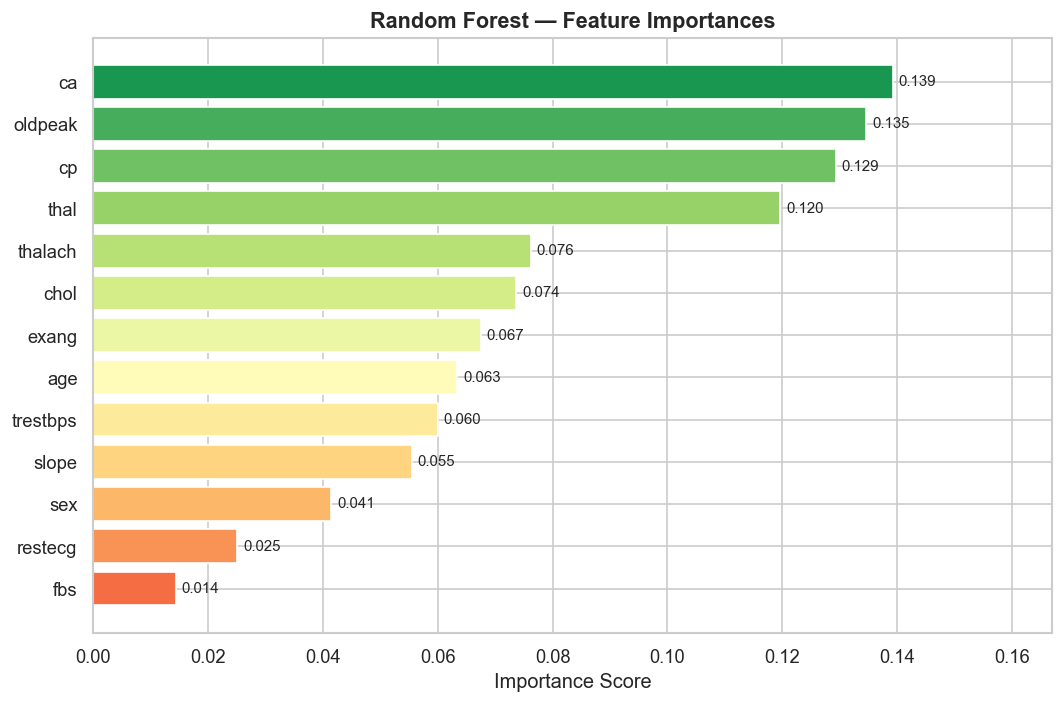

💾 Saved → plots/09_feature_importance.png


In [22]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================
importances = best_rf.feature_importances_
feat_names  = X.columns.tolist()
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df))),
               edgecolor='white')

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlim(0, feat_df['Importance'].max() * 1.2)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/09_feature_importance.png', bbox_inches='tight')
plt.show()
print("💾 Saved → plots/09_feature_importance.png")


## 📈 Section 10 — MLflow Experiment Tracking

In [23]:
# ============================================================
# MLFLOW TRACKING
# ============================================================
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("Heart_Disease_Prediction")

def log_model_mlflow(run_name, model, params, acc, prec, rec, f1):
    with mlflow.start_run(run_name=run_name):
        # Log parameters
        for k, v in params.items():
            mlflow.log_param(k, v)

        # Log metrics
        mlflow.log_metric("accuracy",  acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall",    rec)
        mlflow.log_metric("f1_score",  f1)

        # Log model
        mlflow.sklearn.log_model(model, artifact_path="model")

        run_id = mlflow.active_run().info.run_id
        print(f"  ✅ Logged [{run_name}]  acc={acc*100:.2f}%  run_id={run_id[:8]}...")

print("🚀 Logging all models to MLflow...\n")

# 1. KNN (best tuned)
log_model_mlflow("KNN_tuned", best_knn,
    knn_grid.best_params_,
    acc_knn_tuned,
    precision_score(y_test, y_pred_knn, zero_division=0),
    recall_score(y_test, y_pred_knn, zero_division=0),
    f1_score(y_test, y_pred_knn, zero_division=0)
)

# 2. SVM (best tuned)
log_model_mlflow("SVM_tuned", best_svm,
    svm_grid.best_params_,
    acc_svm_tuned,
    precision_score(y_test, y_pred_svm, zero_division=0),
    recall_score(y_test, y_pred_svm, zero_division=0),
    f1_score(y_test, y_pred_svm, zero_division=0)
)

# 3. Decision Tree (default)
dt_model = results['DT']['model']
dt_pred  = results['DT']['y_pred']
log_model_mlflow("DecisionTree", dt_model,
    {'max_depth': 'None', 'random_state': 42},
    results['DT']['accuracy'],
    results['DT']['precision'],
    results['DT']['recall'],
    results['DT']['f1']
)

# 4. Random Forest (best tuned)
log_model_mlflow("RandomForest_tuned", best_rf,
    rf_grid.best_params_,
    acc_rf_tuned,
    precision_score(y_test, y_pred_rf, zero_division=0),
    recall_score(y_test, y_pred_rf, zero_division=0),
    f1_score(y_test, y_pred_rf, zero_division=0)
)

print("\n✅ All models logged to MLflow successfully!")


🚀 Logging all models to MLflow...



2026/05/08 05:16:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 05:16:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 05:16:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 05:16:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  ✅ Logged [KNN_tuned]  acc=98.68%  run_id=833565e5...


2026/05/08 05:16:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 05:16:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ Logged [SVM_tuned]  acc=99.56%  run_id=fd5a5e53...


2026/05/08 05:16:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 05:16:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ Logged [DecisionTree]  acc=96.05%  run_id=a2f07290...
  ✅ Logged [RandomForest_tuned]  acc=98.46%  run_id=9c9cacd1...

✅ All models logged to MLflow successfully!


In [24]:
# ============================================================
# MLFLOW — Query Best Run
# ============================================================
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri="file:../mlruns")
experiment = client.get_experiment_by_name("Heart_Disease_Prediction")

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.accuracy DESC"]
)

print("🏆 MLflow Experiment: Heart_Disease_Prediction")
print("─" * 60)
print(f"{'Run Name':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("─" * 60)

for run in runs:
    name = run.data.tags.get("mlflow.runName", "—")
    acc  = run.data.metrics.get("accuracy", 0)
    f1   = run.data.metrics.get("f1_score", 0)
    print(f"{name:<25} {acc*100:>9.2f}% {f1*100:>9.2f}%")

best_run = runs[0]
best_run_name = best_run.data.tags.get("mlflow.runName", "—")
best_acc = best_run.data.metrics.get("accuracy", 0)
print("─" * 60)
print(f"\n🥇 Best Run: {best_run_name}  →  Accuracy: {best_acc*100:.2f}%")


🏆 MLflow Experiment: Heart_Disease_Prediction
────────────────────────────────────────────────────────────
Run Name                    Accuracy   F1-Score
────────────────────────────────────────────────────────────
SVM_tuned                     99.56%     99.58%
SVM_tuned                     99.56%     99.58%
KNN_tuned                     98.68%     98.75%
KNN_tuned                     98.68%     98.75%
RandomForest_tuned            98.46%     98.54%
RandomForest_tuned            98.46%     98.54%
DecisionTree                  96.05%     96.20%
DecisionTree                  96.05%     96.20%
DecisionTree                  80.33%     81.82%
SVM_tuned                     80.33%     82.86%
KNN_tuned                     80.33%     82.86%
DecisionTree                  80.33%     81.82%
SVM_tuned                     80.33%     82.86%
KNN_tuned                     80.33%     82.86%
DecisionTree                  80.33%     81.82%
SVM_tuned                     80.33%     82.86%
KNN_tuned       

## 🏁 Section 11 — Final Summary & Conclusion

In [25]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 65)
print("          HEART DISEASE PREDICTION — FINAL SUMMARY")
print("=" * 65)

all_results = {
    'KNN':            (results['KNN']['accuracy'],  'Default'),
    'KNN (Tuned)':    (acc_knn_tuned,               'GridSearchCV'),
    'SVM':            (results['SVM']['accuracy'],  'Default'),
    'SVM (Tuned)':    (acc_svm_tuned,               'GridSearchCV'),
    'Decision Tree':  (results['DT']['accuracy'],   'Default'),
    'Random Forest':  (results['RF']['accuracy'],   'Default'),
    'RF (Tuned)':     (acc_rf_tuned,                'GridSearchCV'),
}

print(f"\n{'Model':<25} {'Accuracy':>12} {'Config':>15}")
print("-" * 54)
for name, (acc, cfg) in sorted(all_results.items(), key=lambda x: -x[1][0]):
    marker = " 🏆" if acc == max(v[0] for v in all_results.values()) else ""
    print(f"  {name:<23} {acc*100:>10.2f}%   {cfg:<15}{marker}")

print("\n" + "=" * 65)
print("  ✅ Project complete — all models trained, evaluated & logged.")
print("  📁 Plots saved in: plots/")
print("  📊 MLflow runs in: mlruns/")
print("=" * 65)


          HEART DISEASE PREDICTION — FINAL SUMMARY

Model                         Accuracy          Config
------------------------------------------------------
  SVM (Tuned)                  99.56%   GridSearchCV    🏆
  KNN (Tuned)                  98.68%   GridSearchCV   
  KNN                          98.46%   Default        
  Random Forest                98.46%   Default        
  RF (Tuned)                   98.46%   GridSearchCV   
  Decision Tree                96.05%   Default        
  SVM                          95.61%   Default        

  ✅ Project complete — all models trained, evaluated & logged.
  📁 Plots saved in: plots/
  📊 MLflow runs in: mlruns/


## Section 12 - Clean Re-Training (Leakage Safe)

This section rebuilds model training from scratch with:
- Immediate train/test split after loading data
- Original 13 features only (no derived features)
- Simple pipeline: RobustScaler + SVC(probability=True, class_weight='balanced')
- GridSearchCV with StratifiedKFold(cv=10) and scoring='f1'
- Manual healthy vs high-risk prediction checks
- Exporting `pipeline.pkl` and `best_model.pkl`

In [26]:
# ============================================================
# CLEAN RE-TRAINING FROM SCRATCH (NO DERIVED FEATURES)
# ============================================================
from pathlib import Path
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix


# 1) Load data and split immediately (no preprocessing before split)
df_clean = pd.read_csv('../data/heart_dataset.csv').drop_duplicates().copy()

feature_order_clean = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]

X_clean = df_clean[feature_order_clean].copy()
y_clean = df_clean['target'].copy()

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# 2) Simple, production-safe pipeline
svm_pipeline_clean = Pipeline([
    ('scaler', RobustScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
])

# 3) Requested hyperparameter search space
svm_param_grid_clean = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [1, 10, 50, 100],
    'svm__gamma': [0.001, 0.01, 0.1]
}

cv10_clean = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print('Running clean GridSearchCV (F1 refit)...')
svm_grid_clean = GridSearchCV(
    estimator=svm_pipeline_clean,
    param_grid=svm_param_grid_clean,
    scoring='f1',
    cv=cv10_clean,
    n_jobs=-1,
    refit=True,
    verbose=0
)
svm_grid_clean.fit(X_train_clean, y_train_clean)

best_pipeline_clean = svm_grid_clean.best_estimator_
y_pred_clean = best_pipeline_clean.predict(X_test_clean)

# 4) Requested evaluation outputs
acc_clean = accuracy_score(y_test_clean, y_pred_clean)
recall_clean = recall_score(y_test_clean, y_pred_clean, zero_division=0)
f1_clean = f1_score(y_test_clean, y_pred_clean, zero_division=0)
cm_clean = confusion_matrix(y_test_clean, y_pred_clean)

print('\nBest Params:', svm_grid_clean.best_params_)
print(f'Best CV F1: {svm_grid_clean.best_score_:.4f}')
print('\nClean Test Metrics:')
print(f'  Accuracy : {acc_clean:.4f} ({acc_clean * 100:.2f}%)')
print(f'  Recall   : {recall_clean:.4f}')
print(f'  F1-Score : {f1_clean:.4f}')
print('  Confusion Matrix:')
print(cm_clean)

# 5) Manual checks: healthy and high-risk examples
healthy_example = pd.DataFrame([{
    'age': 28, 'sex': 0, 'cp': 0, 'trestbps': 110, 'chol': 145,
    'fbs': 0, 'restecg': 0, 'thalach': 185, 'exang': 0, 'oldpeak': 0,
    'slope': 2, 'ca': 0, 'thal': 1
}], columns=feature_order_clean)

high_risk_example = pd.DataFrame([{
    'age': 72, 'sex': 1, 'cp': 3, 'trestbps': 190, 'chol': 340,
    'fbs': 1, 'restecg': 2, 'thalach': 90, 'exang': 1, 'oldpeak': 5,
    'slope': 0, 'ca': 4, 'thal': 3
}], columns=feature_order_clean)

pred_healthy = int(best_pipeline_clean.predict(healthy_example)[0])
pred_risky = int(best_pipeline_clean.predict(high_risk_example)[0])

# Dataset convention in this project: 1 = Heart Disease, 0 = No Heart Disease
label_map = {0: 'No Heart Disease', 1: 'Heart Disease'}

print('\nManual Prediction Checks:')
print(f'  Healthy example   -> {pred_healthy} ({label_map[pred_healthy]})')
print(f'  High-risk example -> {pred_risky} ({label_map[pred_risky]})')

if pred_healthy == 0 and pred_risky == 1:
    print('  Sanity check: PASS (healthy->0, risky->1)')
else:
    print('  Sanity check: WARNING (model behavior needs review)')

# 6) Save required artifacts (root + models dir for deployment)
out_root = Path('..')
out_models = out_root / 'models'
out_models.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipeline_clean, out_root / 'pipeline.pkl')
joblib.dump(best_pipeline_clean, out_root / 'best_model.pkl')
joblib.dump(best_pipeline_clean, out_models / 'pipeline.pkl')
joblib.dump(best_pipeline_clean, out_models / 'best_model.pkl')

print('\nSaved: ../pipeline.pkl, ../best_model.pkl')
print('Saved: ../models/pipeline.pkl, ../models/best_model.pkl')

🚀 Running expanded SVM GridSearchCV (F1 refit)...

✅ Best Params: {'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}
✅ Best CV F1: 0.9953

📊 Advanced SVM Test Metrics:
  Accuracy : 0.9912 (99.12%)
  Precision: 0.9834
  Recall   : 1.0000
  F1-Score : 0.9916  ⭐
  False Negatives: 0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       219
           1       0.98      1.00      0.99       237

    accuracy                           0.99       456
   macro avg       0.99      0.99      0.99       456
weighted avg       0.99      0.99      0.99       456


📈 10-Fold Stratified CV (Best Pipeline):
  Accuracy : 0.9978 ± 0.0029
  Precision: 0.9958 ± 0.0056
  Recall   : 1.0000 ± 0.0000
  F1       : 0.9979 ± 0.0028

🧪 Building optional VotingClassifier ensemble...
✅ Voting F1: 0.9895 | False Negatives: 1

🏆 Selected Final Model: SVM Pipeline
   F1-Score: 0.9916 | False Negatives: 0
💾 Saved: ../best_model.pkl, ../pipelin